In [4]:
import os
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')

from utils.config_dataset import *

RANDOMSEED = 2024
np.random.seed(RANDOMSEED)

In [5]:
save_path = 'processed-merge/'
save_path_merged_data_per_pat = os.path.join(save_path, 'merged_data_per_pat')
sample_dict = pickle.load(open(os.path.join(save_path, 'sample_lookuptable_per_med.p'), 'rb'))

save_path_training_samples = os.path.join(save_path, 'training_samples')
for med in MED_BENCHMARK:
    subpath = os.path.join(save_path_training_samples, med)
    Path(subpath).mkdir(parents=True, exist_ok=True)
    
samples_per_med = {med: [] for med in MED_BENCHMARK}
for med in MED_BENCHMARK:
    for idx in tqdm(sample_dict[med]):
        pid, t_start, t_end = sample_dict[med][idx]
        df = pickle.load(open(os.path.join(save_path_merged_data_per_pat, f"{pid}.p"), 'rb'))
        sample = df.loc[(df.index>=t_start) & (df.index<t_end)]
        samples_per_med[med].append(sample)
        pickle.dump(sample, open(os.path.join(save_path_training_samples, med, f"{pid}.p"), 'wb'))

100%|██████████████| 4497/4497 [00:42<00:00, 105.36it/s]


In [6]:
MED_VASOPRESSOR = ['norepinephrine', 'epinephrine', 'dobutamine']
sample_dict_vasopressor = {}
sample_id = 0
for med in MED_VASOPRESSOR:
    for i in sample_dict[med]:
        sample = sample_dict[med][i]
        sample_dict_vasopressor[sample_id] = [med, sample[0], sample[1], sample[2]]
        sample_id += 1
pickle.dump(sample_dict_vasopressor, open(os.path.join(save_path, 'sample_dict_vasopressor.p'), 'wb'))

In [7]:
patient_info = pickle.load(open('processed-benchmark/patient_info.p', 'rb'))

dischargestatus_vaso = []
for i in tqdm(sample_dict_vasopressor):
    pid = sample_dict_vasopressor[i][1]
    mortality = patient_info[patient_info['patientid']==pid]['discharge_status'].item()
    if mortality == 'alive':
        dischargestatus_vaso.append(0)
    elif mortality == 'dead':
        dischargestatus_vaso.append(1)
    else:
        print(f"UNKNOWN STATUS: {mortality}")

100%|█████████████| 3990/3990 [00:01<00:00, 2614.84it/s]


In [5]:
sample_train, sample_test = train_test_split(list(sample_dict_vasopressor.keys()), 
                                             test_size=0.2, 
                                             random_state=RANDOMSEED, 
                                             stratify=dischargestatus_vaso)
pickle.dump(
    {
        'train': sample_train,
        'test': sample_test
    },
    open(os.path.join(save_path, 'train_test_split_vasopressor.p'), 'wb')
)

In [6]:
df_statistics = []
for i in tqdm(sample_train):
    med, pid, ts_start, ts_end = sample_dict_vasopressor[i]
    sample = pickle.load(open(os.path.join(save_path_training_samples, med, f"{pid}.p"), 'rb'))
    df_statistics.append(sample)
    
df_statistics = pd.concat(df_statistics)
df_statistics[MED_BENCHMARK] = df_statistics[MED_BENCHMARK].replace(.0, np.nan)
df_statistics.shape

100%|███████████████████████████████████████████████████████████████| 3192/3192 [00:03<00:00, 844.89it/s]


(574560, 20)

In [7]:
norm_params = df_statistics.describe(percentiles=[.001, .01, .05, .1, .25, .5, .75, .9, .95, .99, .999])
pickle.dump(norm_params, open(os.path.join(save_path, 'norm_params_vasopressor.p'), 'wb'))
norm_params

,HR,RR,SpO2,ABPd,ABPm,ABPs,ZVD,IN,OUT,OUTurine/h,norepinephrine,epinephrine,dobutamine,Loop diuretics,Benzodiacepine,Propofol,Opiate,resp_failure_status,circ_failure_status,LOS
count,464840.000000,380076.000000,460233.000000,448831.000000,449223.000000,449742.000000,357941.000000,73491.000000,14377.000000,5280.000000,1.509550e+05,5.150200e+04,1.451020e+05,4.426100e+04,1.638520e+05,2.317320e+05,170405.000000,574488.000000,574488.000000,574560.000000
mean,89.519727,14.461045,96.813354,50.677083,67.394172,100.617087,10.127622,339.247959,282.466406,119.170550,5.501696e+00,6.149603e+00,1.848220e-01,1.033986e-01,4.634936e-02,4.013313e+00,77.500910,0.905465,0.297284,3.190813
std,19.191972,7.443872,3.757743,11.743771,15.852234,27.400982,4.739700,928.418400,899.100180,141.563289,1.339352e+01,2.651547e+01,8.626939e-02,1.867657e-01,5.946771e-01,1.519972e+01,196.633013,0.924275,0.457063,3.844099
min,0.000000,0.000000,15.000000,10.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,7.891083e-15,8.243354e-15,9.007324e-16,2.969958e-16,7.893458e-15,9.424946e-15,0.000825,0.000000,0.000000,0.001389
0.1%,38.000000,0.000000,64.000000,21.500000,35.000000,44.000000,0.000000,0.000000,0.000000,0.000000,2.325581e-04,3.846154e-04,1.515151e-04,6.944444e-03,1.388429e-03,3.333333e-04,0.006944,0.000000,0.000000,0.052165
1%,46.000000,3.400000,84.000000,30.000000,43.000000,56.500000,1.000000,0.000000,0.000000,0.000000,1.182723e-01,1.664196e-01,3.331470e-02,1.388889e-02,2.777778e-03,3.329823e-02,0.086806,0.000000,0.000000,0.155556
5%,57.000000,5.500000,91.000000,36.000000,49.000000,67.000000,3.000000,0.000000,36.208051,5.215143,6.659639e-01,4.994525e-01,8.324687e-02,1.388889e-02,4.166667e-03,3.331014e-01,20.833333,0.000000,0.000000,0.302778
10%,64.000000,6.500000,93.000000,39.000000,52.000000,72.000000,5.000000,1.601938,45.230438,15.000000,8.331001e-01,8.271867e-01,8.329114e-02,2.777778e-02,4.166667e-03,6.662479e-01,41.666667,0.000000,0.000000,0.411111
25%,78.000000,8.000000,95.000000,43.000000,57.000000,82.000000,7.000000,5.168938,67.844094,36.206898,1.665399e+00,1.664867e+00,1.664880e-01,2.777778e-02,8.333333e-03,1.332223e+00,41.666667,0.000000,0.000000,0.697222
50%,90.000000,13.328572,98.000000,49.000000,64.000000,95.000000,10.000000,14.859688,118.564911,67.605637,2.999934e+00,3.329663e+00,1.665902e-01,5.555556e-02,2.083333e-02,2.212899e+00,41.666667,1.000000,0.000000,1.645833


In [8]:
patient_info = pickle.load(open('processed-merge/patient_info.p', 'rb'))

df_statistics_info = []
for i in sample_dict_vasopressor:
    pid = sample_dict_vasopressor[i][1]
    df_statistics_info.append(patient_info[patient_info['patientid']==pid])
df_statistics_info = pd.concat(df_statistics_info)

norm_params_info = df_statistics_info.describe(percentiles=[.001, .01, .05, .1, .25, .5, .75, .9, .95, .99, .999])
pickle.dump(norm_params_info, open(os.path.join(save_path, 'norm_params_info_vasopressor.p'), 'wb'))
norm_params_info

,patientid,age,APACHE II Group,APACHE IV Group,height
count,3990.000000,3990.000000,2323.000000,1668.000000,3841.000000
mean,17018.506266,65.781955,102.904861,194.347717,171.329086
std,9696.705099,13.746262,4.029391,4.123784,8.534398
min,4.000000,20.000000,98.000000,190.000000,145.000000
0.1%,29.000000,20.000000,98.000000,190.000000,150.000000
1%,254.000000,20.000000,98.000000,190.000000,150.000000
5%,1707.900000,40.000000,98.000000,190.000000,155.000000
10%,3469.800000,50.000000,98.000000,190.000000,160.000000
25%,8588.500000,60.000000,99.000000,190.000000,165.000000
50%,17156.000000,70.000000,102.000000,193.000000,170.000000


In [9]:
display(HTML(samples_per_med['norepinephrine'][0].to_html()))

,HR,RR,SpO2,ABPd,ABPm,ABPs,ZVD,IN,OUT,OUTurine/h,norepinephrine,epinephrine,dobutamine,Loop diuretics,Benzodiacepine,Propofol,Opiate,resp_failure_status,circ_failure_status,LOS
2149-01-09 16:21:40.930,108.0,NaN,97.0,69.0,83.0,108.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.877778
2149-01-09 16:23:40.930,NaN,NaN,96.0,79.0,92.0,117.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.876389
2149-01-09 16:25:40.930,104.0,NaN,95.0,59.0,76.0,102.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.875000
2149-01-09 16:27:40.930,112.0,NaN,97.0,64.0,78.0,104.0,NaN,482.925356,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.873611
2149-01-09 16:29:40.930,98.0,NaN,97.0,59.0,76.0,102.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.872222
2149-01-09 16:31:40.930,100.0,NaN,96.0,68.0,80.0,106.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.870833
2149-01-09 16:33:40.930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.869444
2149-01-09 16:35:40.930,94.5,NaN,97.0,60.5,75.0,98.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.868056
2149-01-09 16:37:40.930,98.0,NaN,97.0,65.0,82.0,108.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.866667
2149-01-09 16:39:40.930,97.0,NaN,97.0,69.0,82.0,107.0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.055556,0.000000,0.000000,0.000000,2.0,0.0,2.865278


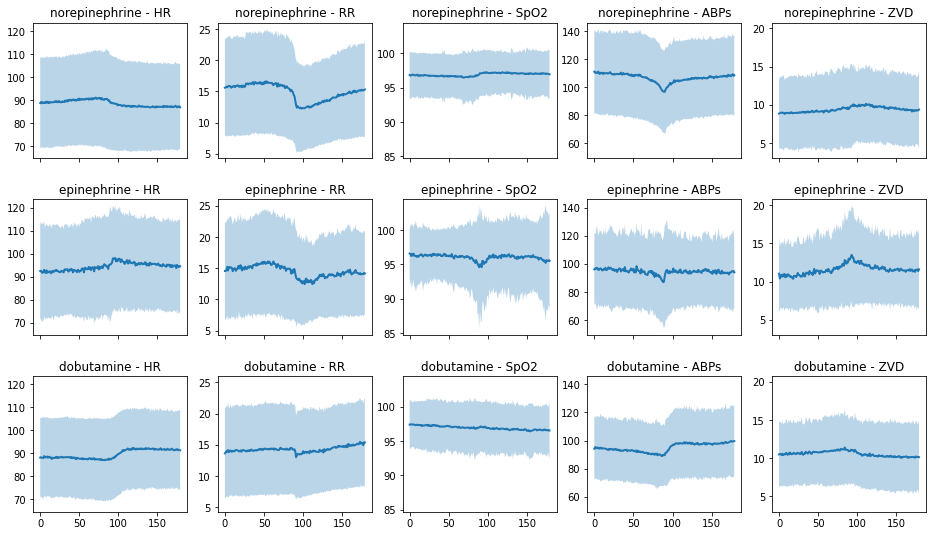

In [10]:
fig, ax = plt.subplots(3, 5, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    dfs = samples_per_med[med]
    for j, physio in enumerate(physio_plot):
        data = [df[physio].reset_index(drop=True) for df in dfs]
        data = pd.concat(data, axis=1)

        mean = data.mean(1)
        std = data.std(1)
            
        ax[i][j].plot(mean, linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean-std, 
                        mean+std, 
                        alpha=.3)
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

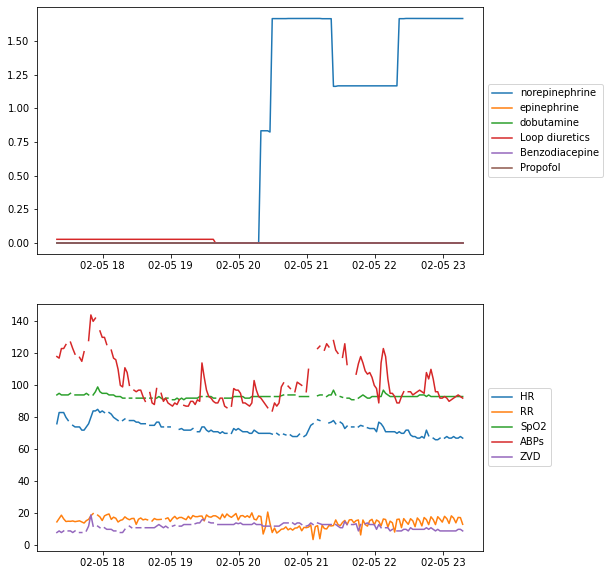

In [152]:
idx = 666
sample = samples_per_med['norepinephrine'][idx]
physio_plot = ['HR', 'RR', 'SpO2', 'ABPs', 'ZVD']

fig, ax = plt.subplots(2, 1, figsize=(8, 10))
for med in MED_BENCHMARK:
    if med == 'Opiate':
        continue
    ax[0].plot(sample[med], label=med)
ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
for physio in physio_plot:
    ax[1].plot(sample[physio], label=physio)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [3]:
from statsmodels.nonparametric.smoothers_lowess import lowess

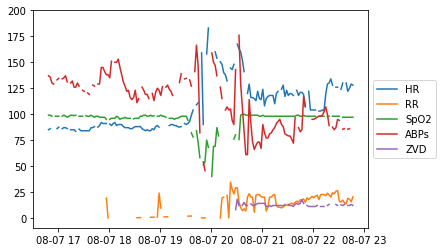

In [71]:
data = samples_per_med['epinephrine'][88]
physio_select = ['HR', 'RR', 'SpO2', 'ABPs', 'ZVD']
plt.plot(data[physio_select]);
plt.legend(physio_select, loc='center left', bbox_to_anchor=(1, 0.5))

In [86]:
physio_select = ['HR', 'RR', 'SpO2', 'ABPs', 'ZVD']
physio = 'HR'


check_idx = []

for med in MED_BENCHMARK[:3]:
    for idx in tqdm(range(len(samples_per_med[med]))):
        for physio in physio_select:
            data = samples_per_med[med][idx]

            data_smoothed = data.reset_index()[physio_select]
            data_ = data_smoothed[physio]
            data_ = data_[~pd.isnull(data_)]
            x = data_.index.to_numpy()
            y = data_.values
            smoothed = lowess(exog=x, endog=y, frac=0.05, xvals=range(180))

            if np.isnan(smoothed).sum() > 0:
                check_idx.append(idx)
                print(idx,' --- ', np.isnan(smoothed).sum(), physio)
                break

  0%|                 | 10/2092 [00:00<00:48, 42.52it/s]

0  ---  180 RR
1  ---  34 HR
2  ---  18 HR
3  ---  180 RR
4  ---  21 HR
5  ---  3 ABPs
6  ---  24 RR
7  ---  5 HR
8  ---  57 HR
9  ---  180 RR


/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/statsmodels/nonparametric/smoothers_lowess.py:233: RuntimeWarning: invalid value encountered in divide
  _, weights = _lowess(y, x, x, np.ones_like(x),
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/statsmodels/nonparametric/smoothers_lowess.py:240: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, xvalues, weights,
  1%|▏                | 16/2092 [00:00<00:42, 48.78it/s]

10  ---  3 HR
11  ---  180 RR
12  ---  25 HR
13  ---  180 RR
14  ---  180 RR
15  ---  6 HR
16  ---  92 RR
17  ---  10 HR
18  ---  73 HR
19  ---  176 RR
20  ---  7 HR
21  ---  180 RR
22  ---  3 

  1%|▏                | 29/2092 [00:00<00:37, 55.17it/s]

...

1388  ---  3 RR
1389  ---  21 SpO2
1390  ---  24 HR
1391  ---  39 RR
1392  ---  35 HR
1393  ---  180 RR
1394  ---  27 SpO2
1395  ---  7 HR
1396  ---  180 RR


 99%|██████████████▉| 1399/1410 [00:35<00:00, 41.34it/s]

1397  ---  30 HR
1399  ---  72 HR
1400  ---  1 HR
1401  ---  7 ABPs


100%|███████████████| 1410/1410 [00:35<00:00, 39.23it/s]

1403  ---  41 HR
1404  ---  63 HR
1405  ---  22 HR
1406  ---  79 SpO2
1407  ---  180 RR
1408  ---  81 HR
1409  ---  20 RR


In [88]:
physio_select = ['HR', 'RR', 'SpO2', 'ABPs', 'ZVD']
physio = 'HR'


check_idx2 = []

for med in MED_BENCHMARK[:3]:
    for idx in tqdm(range(len(samples_per_med[med]))):
        for physio in physio_select:
            data = samples_per_med[med][idx]

            data_smoothed = data.reset_index()[physio_select]
            data_ = data_smoothed[physio]
            data_ = data_[~pd.isnull(data_)]
            x = data_.index.to_numpy()
            y = data_.values
            smoothed = lowess(exog=x, endog=y, frac=0.05)

            if np.isnan(smoothed).sum() > 0:
                check_idx.append(idx)
                print(idx,' --- ', np.isnan(smoothed).sum(), physio)
                break

  0%|                  | 2/2092 [00:00<02:01, 17.13it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
  0%|                  | 8/2092 [00:00<01:46, 19.48it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
  1%|                 | 11/2092 [00:00<01:43, 20.03it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/statsmodels/nonparametric/s

  4%|▋                | 82/2092 [00:04<01:58, 16.93it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
  4%|▋                | 87/2092 [00:04<01:50, 18.14it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _meth

  7%|█               | 139/2092 [00:07<01:38, 19.82it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
  7%|█               | 141/2092 [00:07<01:41, 19.22it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
  7%|█               | 145/2092 [00:07<01:49, 17.74it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3

/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 10%|█▌              | 210/2092 [00:11<01:46, 17.66it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 10%|█▋              | 215/2092 [00:11<01:39, 18.83it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _meth

 14%|██▏             | 289/2092 [00:15<01:36, 18.59it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret /

...

 89%|███████████████▏ | 435/488 [00:24<00:03, 16.37it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 95%|████████████████▏| 465/488 [00:25<00:01, 17.95it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 96%|████████████████▎| 469/488 [00:25<00:01, 17.35it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3

 13%|██▏             | 188/1410 [00:11<01:20, 15.11it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 18%|██▊             | 249/1410 [00:15<01:07, 17.21it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _meth

 46%|███████▍        | 652/1410 [00:40<00:48, 15.68it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 50%|███████▉        | 701/1410 [00:43<00:43, 16.43it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 51%|████████        | 713/1410 [00:44<00:42, 16.38it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3

 66%|██████████▍     | 924/1410 [00:57<00:28, 16.97it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 66%|██████████▌     | 934/1410 [00:58<00:29, 15.95it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 69%|███████████     | 976/1410 [01:00<00:28, 15.21it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3

 94%|██████████████ | 1322/1410 [01:22<00:05, 15.94it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 99%|██████████████▊| 1393/1410 [01:26<00:01, 15.68it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 99%|██████████████▊| 1395/1410 [01:26<00:00, 16.74it/s]/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/statsmodels/nonparametric/s

0


Text(0.5, 1.0, 'HR')

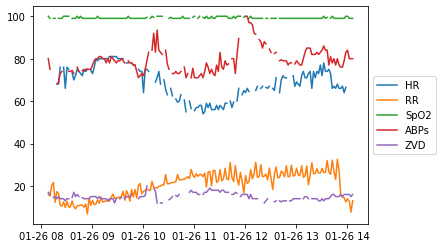

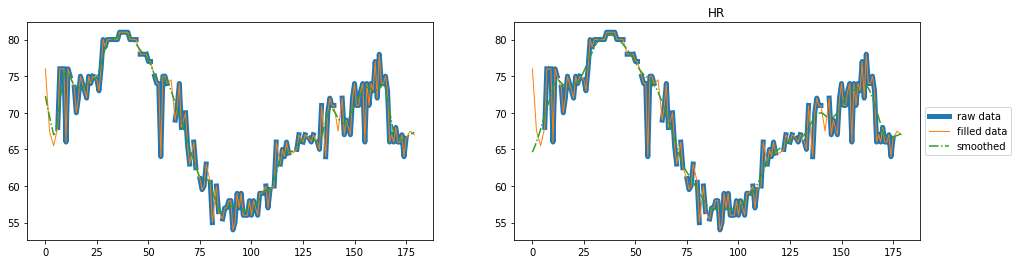

In [133]:
idx = check_idx[60]

data = samples_per_med['epinephrine'][idx]
physio_select = ['HR', 'RR', 'SpO2', 'ABPs', 'ZVD']
plt.plot(data[physio_select]);
plt.legend(physio_select, loc='center left', bbox_to_anchor=(1, 0.5))


physio = 'HR'

data_raw = data.reset_index()[physio_select]
data_filled = data_raw.interpolate(method='linear', limit_area='inside')
data_filled = data_filled.interpolate('ffill')

fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharex=True)

data_ = data_filled[physio]
print(np.isnan(data_).sum())
# data_ = data_[~pd.isnull(data_)]
x = data_.index.to_numpy()
y = data_.values

ax[0].plot(data_raw[physio], label='raw data', linewidth=5)
ax[0].plot(data_filled[physio], label='filled data', linewidth=1)
ax[1].plot(data_raw[physio], label='raw data', linewidth=5)
ax[1].plot(data_filled[physio], label='filled data', linewidth=1)
for frac in [.05]:
    smoothed = lowess(exog=x, endog=y, frac=frac, missing='drop')
    smoothed2 = lowess(exog=x, endog=y, frac=.08)
    ax[0].plot(smoothed[:,0], smoothed[:,1], label=f'lowess_{frac:.2f}', linestyle='-.')

ax[1].plot(smoothed2[:,0], smoothed2[:,1], label='smoothed', linestyle='-.') 
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(physio)

# print(np.isnan(smoothed).sum())

<AxesSubplot:>

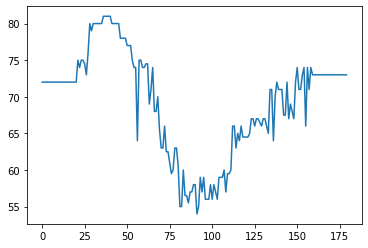

In [139]:
tmp = data_raw['HR']
tmp.iloc[:20] = np.nan
tmp.iloc[-20:] = np.nan

tmp.interpolate('ffill', inplace=True)
tmp.interpolate('bfill', inplace=True)


tmp.plot()

In [141]:
data.index[-1] - data.index[0]

Timedelta('0 days 05:58:00')

In [146]:
180*2/60

6.0

In [145]:
data

,HR,RR,SpO2,ABPd,ABPm,ABPs,ZVD,IN,OUT,OUTurine/h,norepinephrine,epinephrine,dobutamine,Loop diuretics,Benzodiacepine,Propofol,Opiate,resp_failure_status,circ_failure_status,LOS
2162-01-26 08:08:40.300,76.0,15.933333,100.0,40.0,53.0,80.0,17.0,NaN,NaN,NaN,8.331310,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.119444
2162-01-26 08:10:40.300,NaN,15.250000,99.0,37.0,51.0,75.0,16.0,2021.423839,NaN,NaN,8.331310,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.118056
2162-01-26 08:12:40.300,67.5,20.225000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.331310,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.116667
2162-01-26 08:14:40.300,NaN,21.666667,99.0,35.0,44.5,69.0,14.5,NaN,NaN,NaN,8.331310,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.115278
2162-01-26 08:16:40.300,65.5,12.325000,99.0,34.0,44.0,NaN,15.0,NaN,NaN,NaN,8.331310,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.113889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162-01-26 13:58:40.300,66.5,12.475000,100.0,39.0,51.0,83.0,16.0,NaN,NaN,NaN,8.663639,3.330333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.876389
2162-01-26 14:00:40.300,NaN,13.960000,100.0,39.0,51.0,84.0,16.0,NaN,NaN,NaN,8.663639,3.330333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.875000
2162-01-26 14:02:40.300,67.5,12.833333,99.0,38.0,49.0,80.0,16.0,NaN,NaN,NaN,8.663639,3.330333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.873611
2162-01-26 14:04:40.300,NaN,7.666667,99.0,38.0,49.0,80.0,15.0,NaN,NaN,NaN,8.663639,3.330333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.872222


In [18]:
x, y = 3,3
r_map = []
for i in range(10):
    r = []
    for j in range(10):
        r_ = np.sqrt((i-x)**2 + (j-y)**2)
        r.append(r_)
    r_map.append(r)
    print('   '.join('{:.2f}'.format(r_) for r_ in r))
    
r_mat = np.array(r_map).reshape(10, 10)

4.24   3.61   3.16   3.00   3.16   3.61   4.24   5.00   5.83   6.71
3.61   2.83   2.24   2.00   2.24   2.83   3.61   4.47   5.39   6.32
3.16   2.24   1.41   1.00   1.41   2.24   3.16   4.12   5.10   6.08
3.00   2.00   1.00   0.00   1.00   2.00   3.00   4.00   5.00   6.00
3.16   2.24   1.41   1.00   1.41   2.24   3.16   4.12   5.10   6.08
3.61   2.83   2.24   2.00   2.24   2.83   3.61   4.47   5.39   6.32
4.24   3.61   3.16   3.00   3.16   3.61   4.24   5.00   5.83   6.71
5.00   4.47   4.12   4.00   4.12   4.47   5.00   5.66   6.40   7.21
5.83   5.39   5.10   5.00   5.10   5.39   5.83   6.40   7.07   7.81
6.71   6.32   6.08   6.00   6.08   6.32   6.71   7.21   7.81   8.49


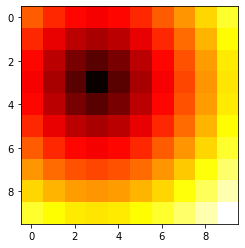

In [20]:
plt.imshow(r_mat, cmap='hot', interpolation='nearest')

In [25]:
(90-6) / 3 

28.0

In [5]:
check =  pd.read_parquet('hirid_benchmark/general_table_extended.parquet')
check

,patientid,admissiontime,sex,age,discharge_status,APACHE II Group,APACHE IV Group,height
0,1,2197-04-03 19:15:00,M,75,alive,NaN,199.0,180.0
1,2,2117-10-18 22:35:00,M,80,alive,103.0,NaN,170.0
2,3,2163-10-17 19:15:00,M,55,alive,107.0,NaN,185.0
3,4,2149-01-08 15:30:00,M,75,alive,NaN,190.0,170.0
4,5,2144-06-06 16:15:00,M,20,alive,NaN,194.0,180.0
...,...,...,...,...,...,...,...,...
33900,33901,2119-06-15 21:55:00,M,70,alive,98.0,NaN,185.0
33901,33902,2182-12-12 21:20:00,F,75,alive,NaN,191.0,170.0
33902,33903,2176-06-21 12:00:00,M,65,alive,NaN,202.0,175.0
33903,33904,2162-03-19 23:35:00,F,70,alive,102.0,NaN,170.0


In [5]:
import pickle
import os

data_path = '../processed-merge/'
sample_dict = pickle.load(open(os.path.join(data_path, 'sample_dict_vasopressor.p'), 'rb'))
sample_dict

{0: ['norepinephrine',
  4,
  Timestamp('2149-01-09 16:21:40.930000'),
  Timestamp('2149-01-09 22:21:40.930000')],
 1: ['norepinephrine',
  18,
  Timestamp('2158-05-17 01:50:04.040000', freq='2T'),
  Timestamp('2158-05-17 07:50:04.040000', freq='2T')],
 2: ['norepinephrine',
  29,
  Timestamp('2124-11-23 18:25:45.070000', freq='2T'),
  Timestamp('2124-11-24 00:25:45.070000', freq='2T')],
 3: ['norepinephrine',
  36,
  Timestamp('2157-08-04 06:59:18.850000'),
  Timestamp('2157-08-04 12:59:18.850000')],
 4: ['norepinephrine',
  52,
  Timestamp('2169-11-02 14:28:22.890000', freq='2T'),
  Timestamp('2169-11-02 20:28:22.890000', freq='2T')],
 5: ['norepinephrine',
  69,
  Timestamp('2142-07-15 05:32:00.090000'),
  Timestamp('2142-07-15 11:32:00.090000')],
 6: ['norepinephrine',
  97,
  Timestamp('2152-01-11 07:21:30.300000'),
  Timestamp('2152-01-11 13:21:30.300000')],
 7: ['norepinephrine',
  104,
  Timestamp('2107-10-14 07:36:31.490000'),
  Timestamp('2107-10-14 13:36:31.490000')],
 8: ['

In [18]:
pharmaref[pharmaref['metavariablename'].isin(MED_VASOPRESSOR)]

,metavariableid,category,variablename,pharmaid,lowerbound,upperbound,normalvalue,type,group,metavariablename,metavariableunit,subgroup,variableunit,conversionsource,unitconversionfactor,pharmaactingperiod,mean,standard_deviation,description,pharmaactingperiod_min
59,39,treatment parameters circulation,Noradrenalin 1mg/ml,1000462.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,norepinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Noradrenalin 1mg/ml,5
60,39,treatment parameters circulation,Noradrenalin 100 ï¿½g/ml Perfusor,1000656.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,norepinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Noradrenalin 100 Âµg/ml Perfusor,5
61,39,treatment parameters circulation,Noradrenalin 20 ï¿½g/ml Perfusor,1000657.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,norepinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Noradrenalin 20 Âµg/ml Perfusor,5
62,39,treatment parameters circulation,Noradrenalin 10 ï¿½g/ml Bolus,1000658.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,norepinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Noradrenalin 10 Âµg/ml Bolus,5
63,40,treatment parameters circulation,Adrenalin 1mg/ml,71.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,epinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Adrenalin 1mg/ml,5
64,40,treatment parameters circulation,Adrenalin 20 ï¿½g/ml Perfusor,1000649.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,epinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Adrenalin 20 Âµg/ml Perfusor,5
65,40,treatment parameters circulation,Adrenalin 100 ï¿½g/ml Perfusor,1000650.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,epinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Adrenalin 100 Âµg/ml Perfusor,5
66,40,treatment parameters circulation,Adrenalin 10 ï¿½g/ml Bolus,1000655.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,epinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Adrenalin 10 Âµg/ml Bolus,5
67,40,treatment parameters circulation,Adrenalin 100 ï¿½g/ml Bolus,1000750.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,epinephrine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Adrenalin 100 Âµg/ml Bolus,5
68,41,treatment parameters circulation,Dobutrex 250 mg/20ml,426.0,NaN,NaN,0,pharma,rates of vaspressor/inotropes,dobutamine,Flow rate,NaN,NaN,NaN,NaN,very short,NaN,NaN,Dobutrex 250 mg/20ml,5


In [20]:
pharmaref[pharmaref['metavariablename'].isin(MED_VASOPRESSOR)].to_csv('/home/kai/DigitalICU/hirid_vasopressor_convert.csv')

In [21]:
pharmaref[pharmaref['metavariablename'].isin(MED_BENCHMARK)].to_csv('/home/kai/DigitalICU/hirid_med_convert.csv')